# A demo of generating synthetic handwritten images using variational autoencoders

> Ensure that you are runing this notebook from the repository root: `./vae-mnist/

> If the training parameters in `train.py` are changed, the output directory names change too. Update the paths when loading weights in the configuration cell below.

## Training the models
Train both the VAE and the Conditional VAE models, which saves model weights that will loaded by this notebook. 

> It's best if the models are trained on the terminal, preferably using a CUDA-enabled PyTorch installation on a GPU.

To train the models, run:
```sh
python train.py vae
python train.py conditional_vae
```

## Setup and Configuration

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from models.vae import VAE
from models.cvae import CVAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


VAE_WEIGHTS = "outputs/vae epoch_10 lr_0.001 bsize_64/weights.pth"
CVAE_WEIGHTS = "outputs/conditional_vae epoch_10 lr_0.001 bsize_64/weights.pth"

LATENT_DIM = 20     # default, as defined in models/vae.py and models/cvae.py
NUM_CLASSES = 10    # 10 digit classes of the MNIST dataset
NUM_SAMPLES = 16    # displayed as a 4x4 grid


# helper functions
@torch.no_grad()
def sample_vae(model, n=NUM_SAMPLES):
    z = torch.randn(n, LATENT_DIM, device=device)
    return model.decoder(z).cpu()


@torch.no_grad()
def sample_cvae(model, digit, n=NUM_SAMPLES):
    z = torch.randn(n, LATENT_DIM, device=device)
    labels = torch.full((n,), digit, dtype=torch.long, device=device)
    return model.decoder(z, labels).cpu()


def show_samples(images, title, rows=4, cols=4, row_labels=None):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.2, rows*1.2), squeeze=False)
    fig.suptitle(title)
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    for image, ax in zip(images, axes.flat):
        ax.imshow(image.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
    if row_labels is not None:
        for row, label in enumerate(row_labels):
            axes[row][0].set_ylabel(label, rotation=0, labelpad=12, va="center", fontsize=11)
    fig.tight_layout()
    plt.show()


cpu


# Using the vanilla VAE for generation

The vanilla VAE takes no direction. A latent vector is drawn at random, and which digit is generated depends on where in the random latent vector happened to land in the latent space.

This model cannot be asked for a specific digit. It never saw class labels during training, so its
latent space holds no digit axis and no record of which region corresponds to which class.

In [4]:
# Load trained model weights
vae = VAE(latent_dim=LATENT_DIM).to(device)
vae.load_state_dict(torch.load(VAE_WEIGHTS, map_location=device))
vae.eval()

VAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
    (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=20, out_features=6272, bias=True)
    (deconv1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (deconv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (deconv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

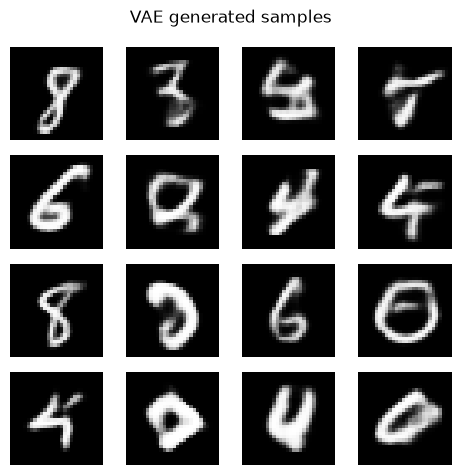

In [11]:
# Re-run this cell for a fresh set of generated samples
images = sample_vae(vae)
show_samples(images, "VAE generated samples")

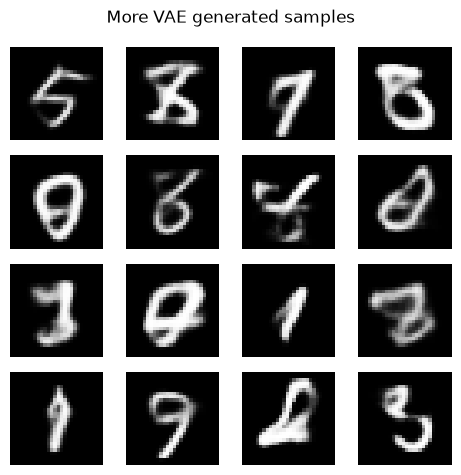

In [13]:
# Let's generate a different set of images
images = sample_vae(vae)
show_samples(images, "More VAE generated samples")

# Using the Conditional VAE for generation

The conditional VAE takes in an argument that specifies which digit to generate.

In [14]:
# Load trained model weights
cvae = CVAE(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
cvae.load_state_dict(torch.load(CVAE_WEIGHTS, map_location=device))
cvae.eval()

CVAE(
  (encoder): Encoder(
    (conv1): Conv2d(11, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc_mu): Linear(in_features=3136, out_features=20, bias=True)
    (fc_logvar): Linear(in_features=3136, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=30, out_features=6272, bias=True)
    (deconv1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (deconv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (deconv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

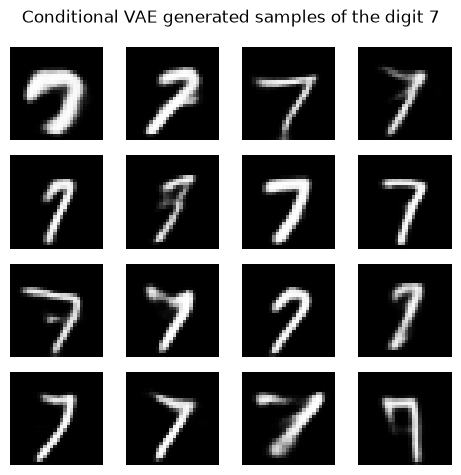

In [18]:
# Re-run this cell for a fresh set of generated samples

digit = 7   # You can change `digit` below to any value from 0 to 9

images = sample_cvae(cvae, digit)
show_samples(images, f"Conditional VAE generated samples of the digit {digit}")

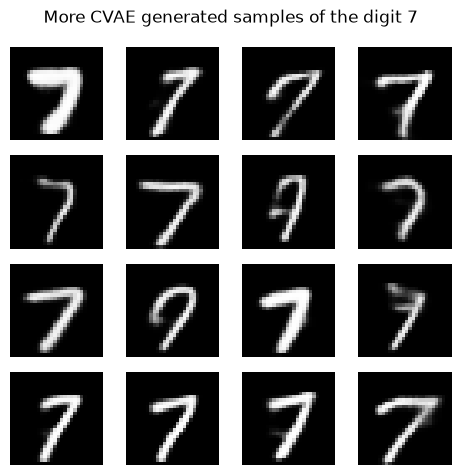

In [19]:
# Let's generate a different set of digit 7 images 
digit = 7
images = sample_cvae(cvae, digit)
show_samples(images, f"More CVAE generated samples of the digit {digit}")

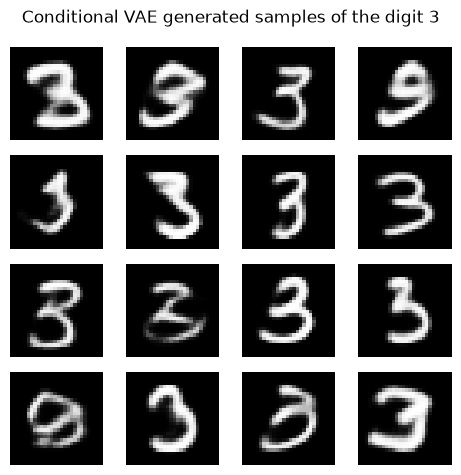

In [27]:
# Let's generate a different digit
digit = 3
images = sample_cvae(cvae, digit)
show_samples(images, f"Conditional VAE generated samples of the digit {digit}")

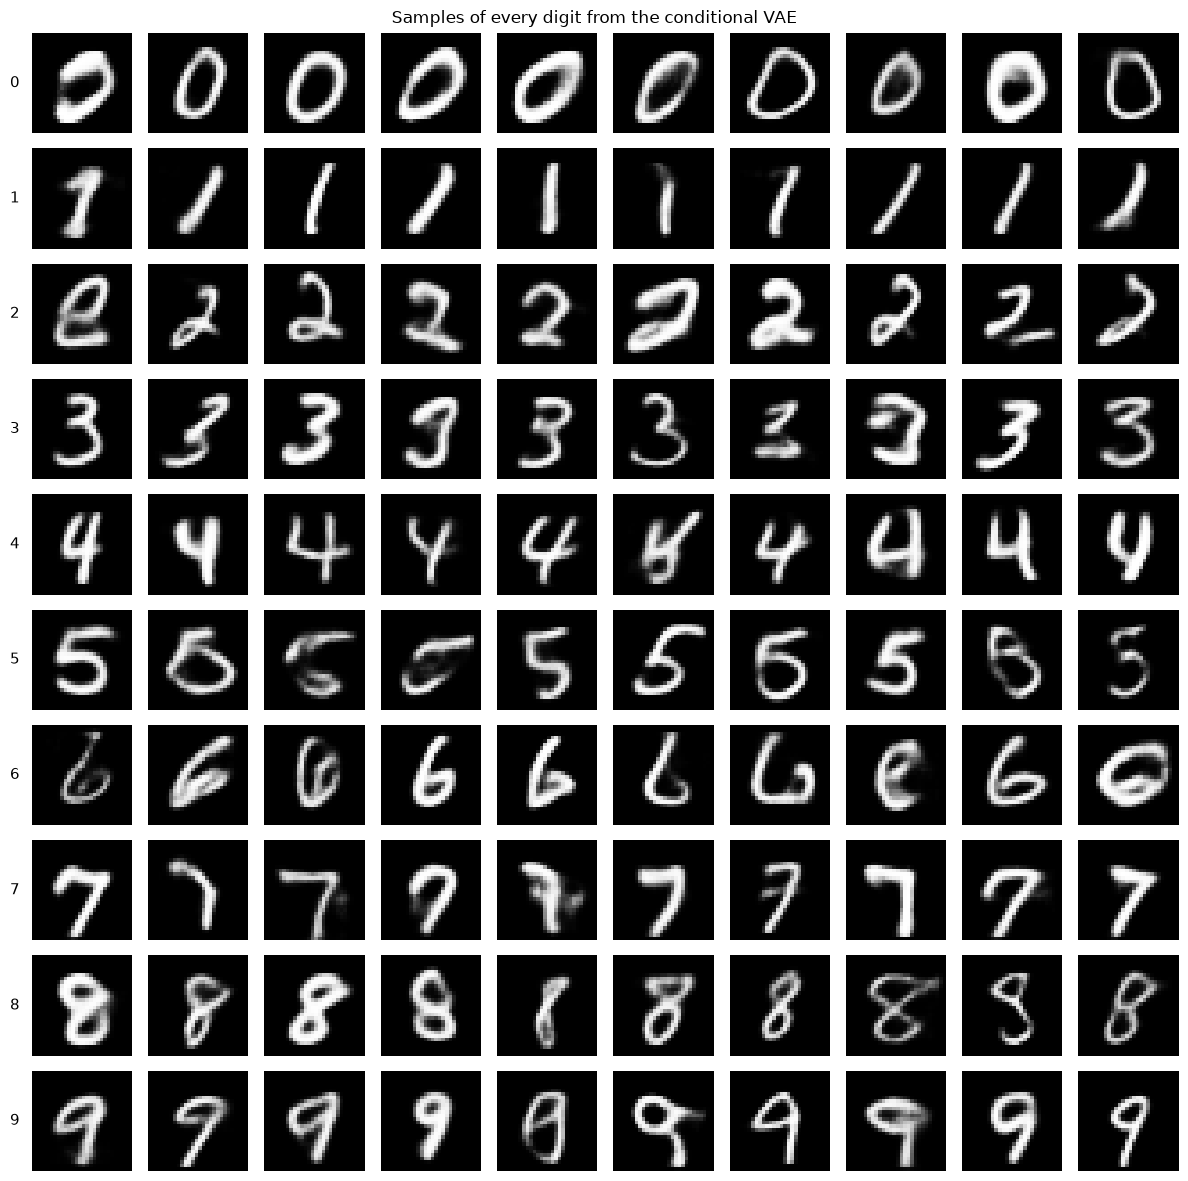

In [28]:
# Sampling images from every class across all ten digits
SAMPLES_PER_DIGIT = 10

images = torch.cat([sample_cvae(cvae, d, SAMPLES_PER_DIGIT) for d in range(NUM_CLASSES)])
show_samples(
    images,
    "Samples of every digit from the conditional VAE",
    rows=NUM_CLASSES, cols=SAMPLES_PER_DIGIT,
    row_labels=[str(d) for d in range(NUM_CLASSES)]
)